In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate
from helper import *
import seaborn as sns
sns.set_style("darkgrid")


## Constants

In [57]:
mu_sun= 1.327e11 ## km^3/s^2  
mu_earth= 3.986e5 ## km^3/s^2  # 3.986e5
mu_mars= 4.2830e4 ## km^3/s^2

SOI_earth = 923502.24 # km
SOI_mars = 577723.87 # km 577723.87 

D_mars = 2.279e8
D_earth = 1.496e8

r_LEO = 463
R_LEO = 6378.2 + r_LEO

w_earth = 1.99177621e-7 # rad/s
w_mars = 1.05850987e-7 # rad/s

r_LMO = 200
R_LMO = 3397.0 + r_LMO

## Geocentric Phase

Positions relative to Earth unless specified

In [58]:
# rPEx0 = R_LEO*np.cos(thetaPE0) # thetaPE0 to be perscribed
# rPEy0 = R_LEO*np.sin(thetaPE0) # thetaPE0 to be perscribed

# vPEx0 = -(np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.sin(thetaPE0)
# vPEy0 = -(np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.cos(thetaPE0)

# y0 = np.array([rPEx0, rPEy0, vPEx0, vPEy0])
# print(y0)

In [103]:
def four_body_ODE_geo( t, state , init_phase): # init phase in radians 
    rPEx, rPEy, vPEx, vPEy = state 
    rPE = np.array([rPEx, rPEy])
    rPE_norm = np.linalg.norm(rPE)

    rx_earth = D_earth*np.cos(w_earth*t)
    ry_earth = D_earth*np.sin(w_earth*t)
    r_earth = np.array([rx_earth, ry_earth])
    r_earth_norm = np.linalg.norm(r_earth)

    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])

    vx_earth = -w_earth*D_earth*np.sin(w_earth*t)
    vy_earth = w_earth*D_earth*np.cos(w_earth*t)
    v_earth = np.array([vx_earth, vy_earth])

    vx_mars = -w_mars*D_mars*np.sin(w_mars*t + init_phase)
    vy_mars = w_mars*D_mars*np.cos(w_mars*t + init_phase)
    v_earth = np.array([vx_mars, vy_mars])

    # Relative vectors (Spacecraft to Planet)
    rP = rPE + r_earth 
    rP_norm = np.linalg.norm(rP)

    rPM = rP - r_mars       # I think
    rPM_norm = np.linalg.norm(rPM)

    aPEx = (-((mu_sun / (rP_norm**3)) * (rPEx + rx_earth))
    - ((mu_earth / (rPE_norm**3)) * (rPEx))
    - ((mu_mars / (rPM_norm**3)) * (rPEx + rx_earth - rx_mars))
    + ((mu_sun / (r_earth_norm**3)) * (rx_earth)))

    # aPEx = - ((mu_earth / (rPE_norm**3)) * (rPEx))
#     print(aPEx)
#     print(f"""
# {-((mu_sun / (rP_norm**3)) * (rPEx + rx_earth))}
# {- ((mu_earth / (rPE_norm**3)) * (rPEx))}
# {- ((mu_mars / (rPM_norm**3)) * (rPEx + rx_earth - rx_mars))}
# {+ (mu_sun / (r_earth_norm**3)) * (rx_earth)}
# """)

    aPEy = (-((mu_sun / (rP_norm**3)) * (rPEy + ry_earth)) 
    - ((mu_earth / (rPE_norm**3)) * (rPEy)) 
    - ((mu_mars / (rPM_norm**3)) * (rPEy + ry_earth - ry_mars)) 
    + ((mu_sun / (r_earth_norm**3)) * (ry_earth)))

    # aPEy = - ((mu_earth / (rPE_norm**3)) * (rPEy))


#     print(f"""
# {-((mu_sun / (rP_norm**3)) * (rPEy + ry_earth))}
# {- ((mu_earth / (rPE_norm**3)) * (rPEy))}
# {- ((mu_mars / (rPM_norm**3)) * (rPEy + ry_earth - ry_mars))}
# {+ (mu_sun / (r_earth_norm**3)) * (ry_earth)}
# """)
    return [vPEx, vPEy, aPEx, aPEy]

# state = four_body_ODE_geo(0,y0 , 30)
# print(state)



In [60]:
# thetaPE0 = 0
# deltaV_LEO = 0
# init_phase = np.deg2rad(30)
# # R_LEO is rPE(0)

In [61]:
# t = np.linspace(1,100000, 10000)
# sol = integrate.odeint(four_body_ODE_geo,y0 = y0 , t = t, args=(init_phase,))

# rPEx_sol = sol.T[0]
# rPEy_sol = sol.T[1]
# vPEx_sol = sol.T[2]
# vPEy_sol = sol.T[3]

In [62]:
# timespan 
tspan = 100*60.0

# timestep 
dt = 100

# total steps
n_steps = int(np.ceil(tspan/dt))
step = 1

# Parameters
thetaPE0 = np.deg2rad(297.573)
deltaV_LEO = 3.514668
init_phase = np.deg2rad(44.141)

# initial conditions
rPEx0 = R_LEO*np.cos(thetaPE0) # thetaPE0 to be perscribed
rPEy0 = R_LEO*np.sin(thetaPE0) # thetaPE0 to be perscribed

vPEx0 = -(np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.sin(thetaPE0)
vPEy0 = (np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.cos(thetaPE0)
print(np.sqrt(mu_earth/R_LEO) * np.sin(thetaPE0))
print(vPEy0)

y0 =np.array([rPEx0, rPEy0, vPEx0, vPEy0], None)
t0 = 0

ys = y0
ts = [0]
step = 0
print(y0)
print(ts)



-6.766170445287298
5.160073305223951
[ 3.16664351e+03 -6.06418885e+03  9.88164879e+00  5.16007331e+00]
[0]


In [63]:
solver = integrate.ode(four_body_ODE_geo)
solver.set_integrator("lsoda") #  
solver.set_initial_value(y0, t0)
solver.set_f_params(init_phase)

while solver.successful():
    solver.integrate(solver.t + dt)
    ys = np.vstack((ys,solver.y))
    ts = np.vstack((ts, solver.t))
    step += 1
    # print(ys[step,:2 ])
    # print(solver.get_return_code())
    if np.linalg.norm(ys[step,:2]) > SOI_earth:
        break

print(ys)
print(ts)





[[ 3.16664351e+03 -6.06418885e+03  9.88164879e+00  5.16007331e+00]
 [ 4.13315268e+03 -5.51166951e+03  9.43018348e+00  5.87646465e+00]
 [ 5.04956415e+03 -4.89218983e+03  8.88549071e+00  6.49458535e+00]
 ...
 [ 3.42173157e+04  9.22531054e+05  2.69888411e-02  2.92809930e+00]
 [ 3.42200145e+04  9.22823861e+05  2.69880320e-02  2.92804899e+00]
 [ 3.42227133e+04  9.23116664e+05  2.69872249e-02  2.92799870e+00]]
[[0.000e+00]
 [1.000e+02]
 [2.000e+02]
 ...
 [2.849e+05]
 [2.850e+05]
 [2.851e+05]]


In [64]:
def integrate_geo():
    solver = integrate.ode(four_body_ODE_geo)
    solver.set_integrator("lsoda") #  
    solver.set_initial_value(y0, t0)
    solver.set_f_params(init_phase)

    while solver.successful():
        solver.integrate(solver.t + dt)
        ys = np.vstack((ys,solver.y))
        ts = np.vstack((ts, solver.t))
        step += 1
        # print(ys[step,:2 ])
        # print(solver.get_return_code())
        if np.linalg.norm(ys[step,:2]) > SOI_earth:
            print("Exitted SOI of Earth")
            return ys, ts
        
        if step > 10000:
            return -1
        

    print(ys)
    print(ts)



In [65]:
ys

array([[ 3.16664351e+03, -6.06418885e+03,  9.88164879e+00,
         5.16007331e+00],
       [ 4.13315268e+03, -5.51166951e+03,  9.43018348e+00,
         5.87646465e+00],
       [ 5.04956415e+03, -4.89218983e+03,  8.88549071e+00,
         6.49458535e+00],
       ...,
       [ 3.42173157e+04,  9.22531054e+05,  2.69888411e-02,
         2.92809930e+00],
       [ 3.42200145e+04,  9.22823861e+05,  2.69880320e-02,
         2.92804899e+00],
       [ 3.42227133e+04,  9.23116664e+05,  2.69872249e-02,
         2.92799870e+00]], shape=(2852, 4))

In [66]:
rs = ys[:,:2]
rsx = rs.T[0]
rsy = rs.T[1]

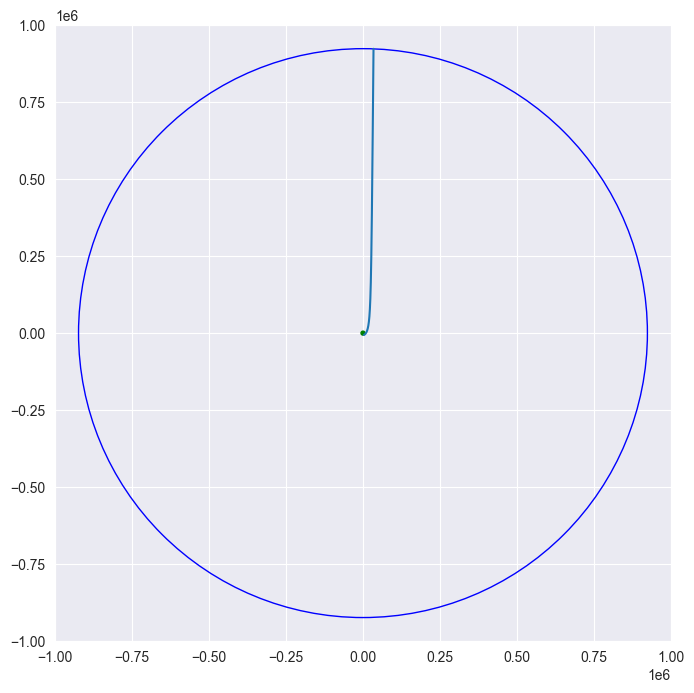

In [67]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
plt.xlim(-1e6,+1e6)
plt.ylim(-1e6,+1e6)

plt.plot(rsx, rsy)
earth = plt.Circle((0,0), 6378.2, color = "g")
earthSOI = plt.Circle((0, 0), SOI_earth, color='b', fill=False)

ax.add_patch(earth)
ax.add_patch(earthSOI)

plt.show()

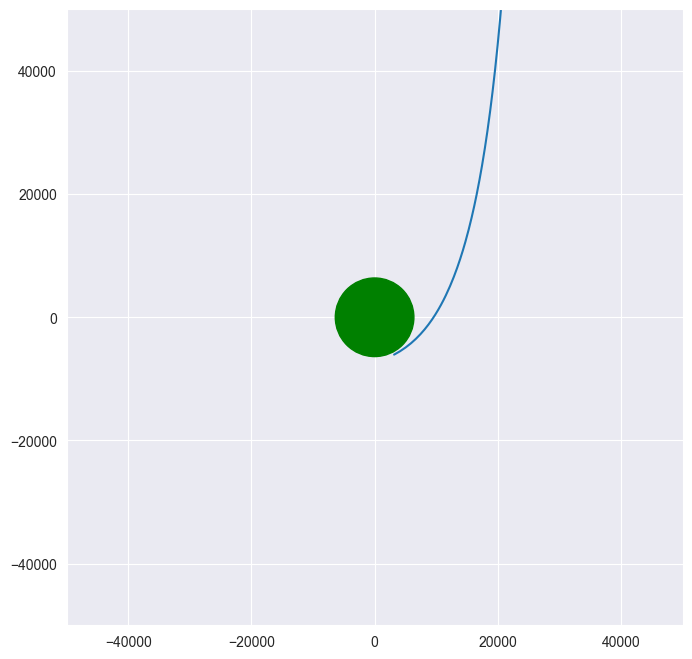

In [68]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
plt.xlim(-5e4,+5e4)
plt.ylim(-5e4,+5e4)

plt.plot(rsx, rsy)
earth = plt.Circle((0,0), 6378.2, color = "g")
earthSOI = plt.Circle((0, 0), SOI_earth, color='b', fill=False)

ax.add_patch(earth)
ax.add_patch(earthSOI)

plt.show()

## Heliocentric Phase   


In [104]:
def four_body_ODE_helio(t, state, init_phase): # init phase in radians 
    rPx, rPy, vPx, vPy = state 
    rP = np.array([rPx, rPy])
    rP_norm = np.linalg.norm(rP)

    rx_earth = D_earth*np.cos(w_earth*t)
    ry_earth = D_earth*np.sin(w_earth*t)
    r_earth = np.array([rx_earth, ry_earth])

    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])

    vx_earth = -w_earth*D_earth*np.sin(w_earth*t)
    vy_earth = w_earth*D_earth*np.cos(w_earth*t)
    v_earth = np.array([vx_earth, vy_earth])

    vx_mars = -w_mars*D_mars*np.sin(w_mars*t + init_phase)
    vy_mars = w_mars*D_mars*np.cos(w_mars*t + init_phase)
    v_earth = np.array([vx_mars, vy_mars])

    rPM = rP - r_mars       # I think
    rPM_norm = np.linalg.norm(rPM)

    rPE = rP = r_earth
    rPE_norm = np.linalg.norm(rPE)

    aPx = (-((mu_sun / (rP_norm**3)) * (rPx))
    - ((mu_earth / (rPE_norm**3)) * (rPx - rx_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPx - rx_mars)))

    aPy = (-((mu_sun / (rP_norm**3)) * (rPy))
    - ((mu_earth / (rPE_norm**3)) * (rPy - ry_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPy - ry_mars)))

    return [vPx, vPy, aPx, aPy]

four_body_ODE_helio(0.5,[10,10,10,10], 10)

[10, 10, np.float64(-469165349.3172742), np.float64(-469165349.3172742)]

In [70]:
def get_rPM_norm(rP, t, debug = False):
    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])
    rPM = rP - r_mars      # I think
    rPM_norm = np.linalg.norm(rPM)
    if debug:
        print(f"""
{rx_mars = }
{ry_mars = }
{r_mars = }
{rPM = }
{rPM_norm = }""")
    return rPM_norm

In [71]:
y1PE = ys[-1]
t1 = ts[-1]

print(y1PE, t1)

[3.42227133e+04 9.23116664e+05 2.69872249e-02 2.92799870e+00] [285100.]


In [72]:
rx_earth1 = D_earth*np.cos(w_earth*t1)
ry_earth1 = D_earth*np.sin(w_earth*t1)

vx_earth1 = -w_earth*D_earth*np.sin(w_earth*t1)
vy_earth1 = w_earth*D_earth*np.cos(w_earth*t1)

rPEx1, rPEy1, vPEx1, vPEy1 = y1PE

# get_rPM_norm([rPEx1,rPEy1], t1)

In [73]:
# timespan 
tspan = 100*60.0

# timestep 
dt = 60*5

# total steps
n_steps = int(np.ceil(tspan/dt))
step = 1

# # Parameters
# thetaPE0 = np.rad2deg(68)
# deltaV_LEO = 3.552
# init_phase = np.deg2rad(30)

# initial conditions
rPx1 = rx_earth1 + rPEx1 
rPy1 = ry_earth1 + rPEy1 

vPx1 = vx_earth1 + vPEx1 
vPy1 = vy_earth1 + vPEy1 


y1 =np.array([rPx1[0].real, rPy1[0].real, vPx1[0].real, vPy1[0].real])
t1 = t1

ys = y1
ts = t1
step = 0
print(y1)
print(t1)


[ 1.49393088e+08  9.41366859e+06 -1.66414071e+00  3.26769421e+01]
[285100.]


In [74]:
solver = integrate.ode(four_body_ODE_helio)
solver.set_integrator("lsoda") #  
solver.set_initial_value(y1, t1[0])
solver.set_f_params(init_phase)

while solver.successful() and step < (100000*8):
    solver.integrate(solver.t + dt)
    # print(solver.t)
    ys = np.vstack((ys,solver.y))
    ts = np.vstack((ts, solver.t))
    step += 1
    # print(f"{solver.y[0]:e} {solver.y[1]}")
    # print(f"{get_rPM_norm([solver.y[0],solver.y[1]], solver.t):e} {SOI_mars:e} {(get_rPM_norm([solver.y[0],solver.y[1]], solver.t) - SOI_mars):e}")
    if (get_rPM_norm([solver.y[0],solver.y[1]], solver.t) - SOI_mars) < 5e5:
        dt = 60

    if get_rPM_norm([solver.y[0],solver.y[1]], solver.t) < SOI_mars:
        print("In SOI")
        break

print(ys, ts)
# print(ts)


KeyboardInterrupt: 

In [ ]:
def integrate_helio():
    solver = integrate.ode(four_body_ODE_helio)
    solver.set_integrator("lsoda") #  
    solver.set_initial_value(y1, t1[0])
    solver.set_f_params(init_phase)

    while solver.successful() and step < (100000*8):
        solver.integrate(solver.t + dt)
        # print(solver.t)
        ys = np.vstack((ys,solver.y))
        ts = np.vstack((ts, solver.t))
        step += 1
        # print(f"{solver.y[0]:e} {solver.y[1]}")
        # print(f"{get_rPM_norm([solver.y[0],solver.y[1]], solver.t):e} {SOI_mars:e} {(get_rPM_norm([solver.y[0],solver.y[1]], solver.t) - SOI_mars):e}")
        if (get_rPM_norm([solver.y[0],solver.y[1]], solver.t) - SOI_mars) < 5e5:
            dt = 60

        if get_rPM_norm([solver.y[0],solver.y[1]], solver.t) < SOI_mars:
            print("Enterred Mars SOI")
            return ys, ts

    print(ys, ts)

In [ ]:
rs = ys[:,:2]
rsx = rs.T[0]
rsy = rs.T[1]

t2 = ts[-1]
# t2 = 257.965*(60*60*24)
t2 = t2[0]
print(t2, (257.965*(60*60*24)))

21951880.0 22288175.999999996


In [ ]:
t3 = ts[-100]
t3 = t3[0]

t4 = ts[-50]
t4 = t4[0]

In [ ]:
rx_mars2 = D_mars*np.cos(w_mars*t2 + init_phase)
ry_mars2 = D_mars*np.sin(w_mars*t2 + init_phase)

print(rx_mars2, ry_mars2)
print(rs[-1])
print(f"{get_rPM_norm(rs[-1], t2, debug = True):e} {SOI_mars}")



-227642313.01059955 10834543.238374867
[-2.27917933e+08  1.03268930e+07]

rx_mars = np.float64(-227642313.01059955)
ry_mars = np.float64(10834543.238374867)
r_mars = array([-2.27642313e+08,  1.08345432e+07])
rPM = array([-275619.79762486, -507650.20636222])
rPM_norm = np.float64(577646.0896278698)
5.776461e+05 577723.87


In [ ]:
rx_mars3 = D_mars*np.cos(w_mars*t3 + init_phase)
ry_mars3 = D_mars*np.sin(w_mars*t3 + init_phase)

print(rx_mars3, ry_mars3)
print(rs[-1])
print(f"{get_rPM_norm(rs[-100], t3, debug = True):e} {SOI_mars}")


-227635455.7420802 10977672.298599634
[-2.27917933e+08  1.03268930e+07]

rx_mars = np.float64(-227635455.7420802)
ry_mars = np.float64(10977672.298599634)
r_mars = array([-2.27635456e+08,  1.09776723e+07])
rPM = array([-275434.01566747, -523622.83561686])
rPM_norm = np.float64(591645.8154725216)
5.916458e+05 577723.87


In [ ]:
rx_mars4 = D_mars*np.cos(w_mars*t4 + init_phase)
ry_mars4 = D_mars*np.sin(w_mars*t4 + init_phase)

print(rx_mars3, ry_mars3)
print(rs[-1])
print(f"{get_rPM_norm(rs[-50], t4, debug = True):e} {SOI_mars}")


-227635455.7420802 10977672.298599634
[-2.27917933e+08  1.03268930e+07]

rx_mars = np.float64(-227638930.25699866)
ry_mars = np.float64(10905385.433321552)
r_mars = array([-2.27638930e+08,  1.09053854e+07])
rPM = array([-275528.0901773 , -515556.36630372])
rPM_norm = np.float64(584563.1662301724)
5.845632e+05 577723.87


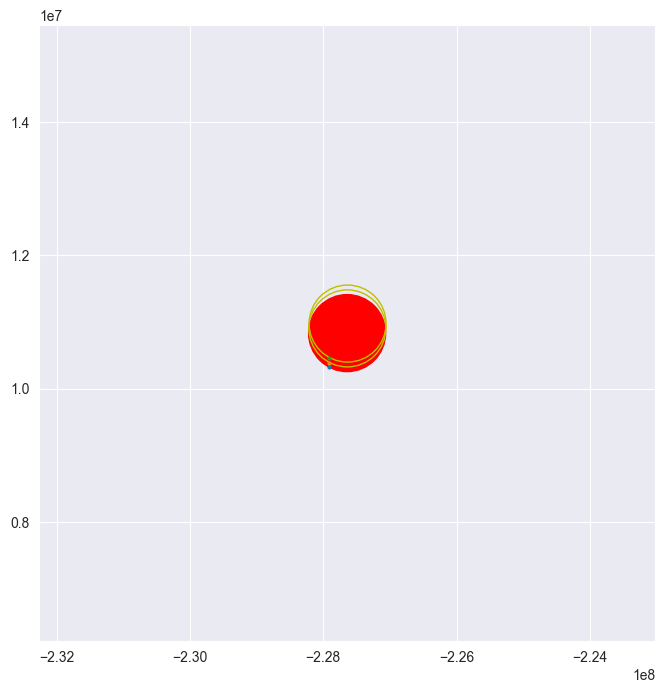

In [ ]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
plt.xlim(rx_mars2 - SOI_mars*8,rx_mars2 + SOI_mars*8)
plt.ylim(ry_mars2 - SOI_mars*8,ry_mars2 + SOI_mars*8)

plt.plot(rsx[-1], rsy[-1], marker = "o", markersize = 2)
plt.plot(rsx[-50], rsy[-50], marker = "o", markersize = 2)
plt.plot(rsx[-100], rsy[-100], marker = "o", markersize = 2)






mars2SOI = plt.Circle((rx_mars2, ry_mars2), SOI_mars*1, color='r', fill=True)
mars3SOI = plt.Circle((rx_mars3, ry_mars3), SOI_mars*1, color='y', fill=False)
mars4SOI = plt.Circle((rx_mars4, ry_mars4), SOI_mars*1, color='y', fill=False)




ax.add_patch(mars2SOI)
ax.add_patch(mars3SOI)
ax.add_patch(mars4SOI)

plt.show()

In [ ]:
# t3 = ts[-2]
# t3 = t3[0]

In [ ]:
# Pos of Earth at t1
rx_earth1 = D_earth*np.cos(w_earth*t1)
ry_earth1 = D_earth*np.sin(w_earth*t1)

# Pos of Mars at t1
rx_mars1 = D_mars*np.cos(w_mars*t1 + init_phase)
ry_mars1 = D_mars*np.sin(w_mars*t1 + init_phase)

# Pos of Mars at t2
rx_mars2 = D_mars*np.cos(w_mars*t2 + init_phase)
ry_mars2 = D_mars*np.sin(w_mars*t2 + init_phase)

# # Pos of Mars at t3
# rx_mars3 = D_mars*np.cos(w_mars*t3 + init_phase)
# ry_mars3 = D_mars*np.sin(w_mars*t3 + init_phase)

print((w_mars*t2))
# Pos of Earth at t2 
rx_earth2 = D_earth*np.cos(w_earth*t2)
ry_earth2 = D_earth*np.sin(w_earth*t2)


2.32362816450556


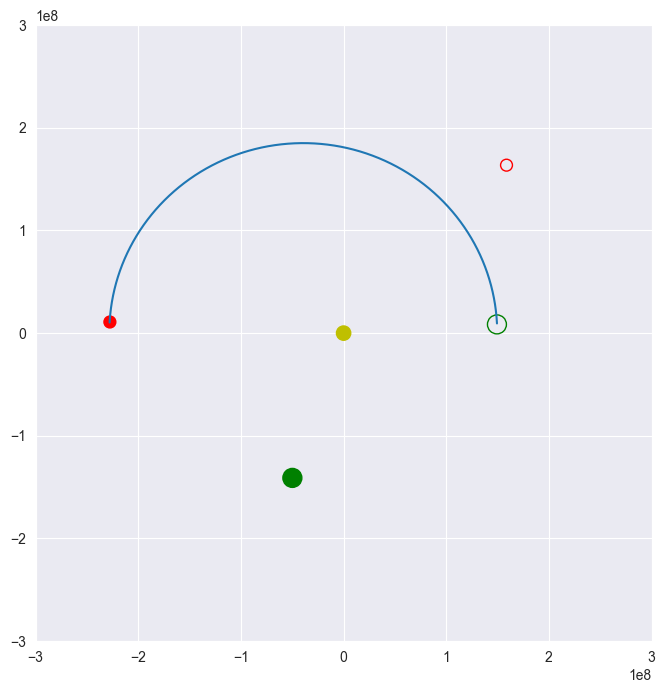

In [ ]:
fig, ax = plt.subplots(figsize = (13,8))

# Scale for Sun and planet SOI visualisation
scaling_factor = 10
ax.set_aspect(1)
plt.xlim(-3e8,+3e8)
plt.ylim(-3e8,+3e8)

plt.plot(rsx, rsy)

earth1SOI = plt.Circle((rx_earth1[0], ry_earth1[0]), SOI_earth*scaling_factor, color='g', fill=False)
earth2SOI = plt.Circle((rx_earth2, ry_earth2), SOI_earth*scaling_factor, color='g', fill=True)

mars1SOI = plt.Circle((rx_mars1[0], ry_mars1[0]), SOI_mars*scaling_factor, color='r', fill=False)
mars2SOI = plt.Circle((rx_mars2, ry_mars2), SOI_mars*scaling_factor, color='r', fill=True)
# mars3SOI = plt.Circle((rx_mars3, ry_mars3), SOI_mars*1, color='y', fill=False)

Sun = plt.Circle((0, 0), 696340*scaling_factor, color='y', fill=True)

ax.add_patch(earth1SOI)
ax.add_patch(earth2SOI)

ax.add_patch(mars1SOI)
ax.add_patch(mars2SOI)
# ax.add_patch(mars3SOI)

ax.add_patch(Sun)

plt.show()

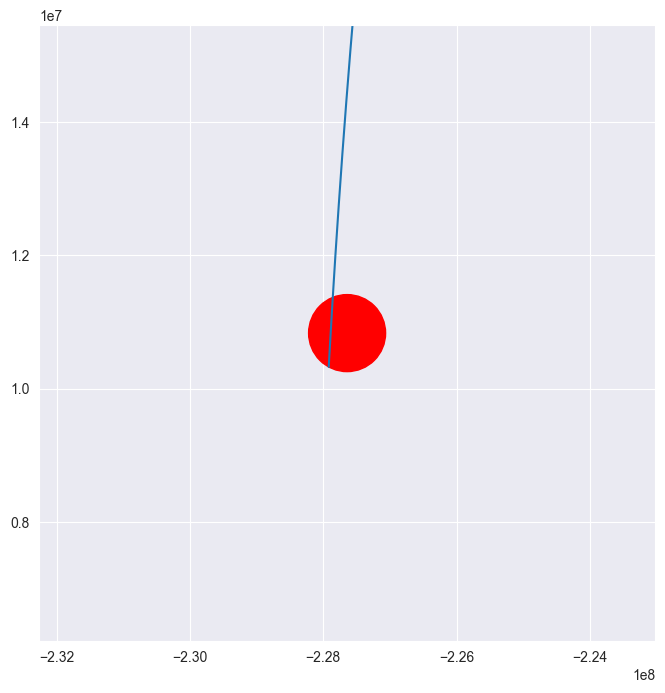

In [ ]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
plt.xlim(rx_mars2 - SOI_mars*8,rx_mars2 + SOI_mars*8)
plt.ylim(ry_mars2 - SOI_mars*8,ry_mars2 + SOI_mars*8)

plt.plot(rsx, rsy)
plt.plot()

earth1SOI = plt.Circle((rx_earth1[0], ry_earth1[0]), SOI_earth*1, color='g', fill=False)
earth2SOI = plt.Circle((rx_earth2, ry_earth2), SOI_earth*1, color='g', fill=True)

mars1SOI = plt.Circle((rx_mars1[0], ry_mars1[0]), SOI_mars*1, color='r', fill=False)
mars2SOI = plt.Circle((rx_mars2, ry_mars2), SOI_mars*1, color='r', fill=True)
# mars3SOI = plt.Circle((rx_mars3, ry_mars3), SOI_mars*1, color='y', fill=False)

Sun = plt.Circle((0, 0), 696340*1, color='y', fill=True)

ax.add_patch(earth1SOI)
ax.add_patch(earth2SOI)

ax.add_patch(mars1SOI)
ax.add_patch(mars2SOI)
# ax.add_patch(mars3SOI)
ax.add_patch(Sun)

plt.show()

## Marscentric 

### Def Constraints

In [105]:
def g1(rPMx, rPMy, debug = False): # Correct Height
    con = rPMx**2 + rPMy**2 - R_LMO**2

    if debug:
        print(f"""
{rPMx**2 + rPMy**2 = }
{R_LMO**2 = }
{con = }""")
        
    return con

def g2(vPMx, vPMy, deltaV_LMO, debug = False): # Correct Velocity
    con = (vPMx**2 + vPMy**2) - (np.sqrt(mu_mars/R_LMO) + deltaV_LMO)**2

    if debug:
        print(f"""
{vPMx**2 + vPMy**2 = }
{(np.sqrt(mu_mars/R_LMO) + deltaV_LMO)**2 = }
{con = }""")
        
    return con

def g3(rPMx, rPMy, vPMx, vPMy, deltaV_LMO, orientation = "clockwise" ,debug = False): # Correct Direction
    LHS = rPMx*vPMy - rPMy*vPMx
    RHS = R_LMO*(np.sqrt(mu_mars/R_LMO) + deltaV_LMO)

    if debug:
        print(f"""
{LHS = }
{RHS = }
""")
    if orientation == "clockwise":
        return LHS + RHS
    
    if orientation == "counterclockwise":
        return LHS - RHS

def g(rPMx, rPMy, vPMx, vPMy, deltaV_LMO, debug = False):
    if debug:
        print(f"""
{g1(rPMx, rPMy)**2 / R_LMO**2}
{g2(vPMx, vPMy, deltaV_LMO)**2}
{g3(rPMx, rPMy, vPMx, vPMy, deltaV_LMO)**2}""")
    return (g1(rPMx, rPMy)**2 / R_LMO**2) +  g2(vPMx, vPMy, deltaV_LMO)**2 + g3(rPMx, rPMy, vPMx, vPMy, deltaV_LMO)**2


In [ ]:
# def g1(rPMx, rPMy, atol = 1, debug = False): # Correct Height
#     con = rPMx**2 + rPMy**2 - R_LMO**2

#     if debug:
#         print(f"""
# {rPMx**2 + rPMy**2 = }
# {R_LMO**2 = }
# {con = }""")
        
#     return con, np.isclose(con, 0, atol=atol)

# def g2(vPMx, vPMy, deltaV_LMO, atol = 0.1, debug = False): # Correct Velocity
#     con = (vPMx**2 + vPMy**2) - (np.sqrt(mu_mars/R_LMO) + deltaV_LMO)**2

#     if debug:
#         print(f"""
# {vPMx**2 + vPMy**2 = }
# {(np.sqrt(mu_mars/R_LMO) + deltaV_LMO)**2 = }
# {con = }""")
        
#     return con, np.isclose(con, 0, atol = atol)

# def g3(rPMx, rPMy, vPMx, vPMy, deltaV_LMO, atol = 0.1, debug = False):
#     LHS = rPMx*vPMy - rPMy*vPMx
#     RHS = R_LMO*(np.sqrt(mu_mars/R_LMO) + deltaV_LMO)

#     if debug:
#         print(f"""
# {LHS = }
# {RHS = }
# {con1 = }
# {con2 = }""")
#     con1 = LHS + RHS # clockwise
#     con2 = LHS - RHS # counter-clockwise
#     return con1, con2, np.isclose(con1,0,atol = atol) or np.isclose(con2,0, atol = atol)


# def g(rPMx, rPMy, vPMx, vPMy, deltaV_LMO, atol1 = 1, atol2 = 0.1, atol3 = 0.1):
#     return (g1(rPMx, rPMy, atol = atol1) and g2(vPMx, vPMy, deltaV_LMO, atol = atol2) and g3(rPMx, rPMy, vPMx, vPMy, deltaV_LMO, atol = atol3))


SyntaxError: expected ':' (1052299396.py, line 1)

### Def ODE

In [106]:
def four_body_ODE_mars( t, state, init_phase): # init phase in radians 
    rPMx, rPMy, vPMx, vPMy = state 
    rPM = np.array([rPMx, rPMy])
    rPM_norm = np.linalg.norm(rPM)

    rx_earth = D_earth*np.cos(w_earth*t)
    ry_earth = D_earth*np.sin(w_earth*t)
    r_earth = np.array([rx_earth, ry_earth])

    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])
    r_mars_norm = np.linalg.norm(r_mars)

    vx_earth = -w_earth*D_earth*np.sin(w_earth*t)
    vy_earth = w_earth*D_earth*np.cos(w_earth*t)
    v_earth = np.array([vx_earth, vy_earth])

    vx_mars = -w_mars*D_mars*np.sin(w_mars*t + init_phase)
    vy_mars = w_mars*D_mars*np.cos(w_mars*t + init_phase)
    v_earth = np.array([vx_mars, vy_mars])

    rPE = rP = r_earth
    rPE_norm = np.linalg.norm(rPE)

    rP = rPE + r_earth 
    rP_norm = np.linalg.norm(rP)

    aPMx = -((mu_sun / (rP_norm**3)) * (rPMx + rx_mars))
    - ((mu_earth / (rPE_norm**3)) * (rPMx + rx_mars - rx_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPMx))
    + ((mu_sun / (r_mars_norm**3)) * (rx_mars))

    aPMy = -((mu_sun / (rP_norm**3)) * (rPMy + ry_mars))
    - ((mu_earth / (rPE_norm**3)) * (rPMy + ry_mars - ry_earth))
    - ((mu_mars / (rPM_norm**3)) * (rPMy))
    + ((mu_sun / (r_mars_norm**3)) * (ry_mars))

    return [vPMx, vPMy, aPMx, aPMy]

four_body_ODE_mars(0.5,[10,10,10,10], 10)

[10, 10, np.float64(9.473913779051102e-07), np.float64(6.142515115038357e-07)]

In [ ]:
y2 = ys[-1]
t2 = ts[-1]

print(y2, t2)

[-2.27917933e+08  1.03268930e+07 -1.17795970e+00 -2.14068215e+01] [21951880.]


In [ ]:
y2_save = ys[-1]
t2_save = ts[-1]

In [ ]:
rPx2, rPy2, vPx2, vPy2 = y2_save
t2 = t2_save

In [ ]:
rx_mars2 = D_mars*np.cos(w_mars*t2 + init_phase)
ry_mars2 = D_mars*np.sin(w_mars*t2 + init_phase)

vx_mars2 = -w_mars*D_mars*np.sin(w_mars*t2 + init_phase)
vy_mars2 = w_mars*D_mars*np.cos(w_mars*t2 + init_phase)

In [ ]:
# timestep 
dt = 100.0

# total steps
n_steps = int(np.ceil(tspan/dt))
step = 1


# Initial Conditions
rPMx2 = rPx2 - rx_mars2
rPMy2 = rPy2 - ry_mars2

vPMx2 = vPx2 - vx_mars2
vPMy2 = vPy2 - vy_mars2


y2 =np.array([rPMx2[0], rPMy2[0], vPMx2[0], vPMy2[0]], None)
# t2 =ts

ys = y2
ts = t2
step = 0
print(ys)
print(ts)


[-2.75619798e+05 -5.07650206e+05 -3.11126070e-02  2.68934200e+00]
[21951880.]


In [ ]:
print(ys)
print(ts)

[-2.75619798e+05 -5.07650206e+05 -3.11126070e-02  2.68934200e+00]
[21951880.]


In [ ]:
deltaV_LMO = 2.087434

In [ ]:
solver = integrate.ode(four_body_ODE_mars)
solver.set_integrator("lsoda") #  
solver.set_initial_value(y2, t2[0])
solver.set_f_params(init_phase)

while solver.successful() and (step <8000):
    solver.integrate(solver.t + dt)
    ys = np.vstack((ys,solver.y))
    ts = np.vstack((ts, solver.t))
    step += 1
    # print(ys[step,:2 ])
    # print(solver.get_return_code())
    if g1(solver.y[0], solver.y[1]) < 100:
        break

    # if g(solver.y[0], solver.y[1], solver.y[2], solver.y[3], deltaV_LMO):
    #     break

print(ys)
print(ts)


[[-2.75619798e+05 -5.07650206e+05 -3.11126070e-02  2.68934200e+00]
 [-2.75622902e+05 -5.07381272e+05 -3.09996886e-02  2.68933688e+00]
 [-2.75625997e+05 -5.07112339e+05 -3.08867701e-02  2.68933177e+00]
 ...
 [ 6.08411594e+04  1.63597451e+06  8.72319718e-01  2.68238416e+00]
 [ 6.09283970e+04  1.63624275e+06  8.72432520e-01  2.68238753e+00]
 [ 6.10156459e+04  1.63651099e+06  8.72545321e-01  2.68239091e+00]]
[[21951880.]
 [21951980.]
 [21952080.]
 ...
 [22751680.]
 [22751780.]
 [22751880.]]


In [ ]:
def integrate_mars():
    solver = integrate.ode(four_body_ODE_mars)
    solver.set_integrator("lsoda") #  
    solver.set_initial_value(y2, t2[0])
    solver.set_f_params(init_phase)

    while solver.successful() and (step <8000):
        solver.integrate(solver.t + dt)
        ys = np.vstack((ys,solver.y))
        ts = np.vstack((ts, solver.t))
        step += 1
        # print(ys[step,:2 ])
        # print(solver.get_return_code())
        if g1(solver.y[0], solver.y[1]) < 100:
            return ys, ts
        
        if step > 8000:
            return -1

    # if g(solver.y[0], solver.y[1], solver.y[2], solver.y[3], deltaV_LMO):
    #     break

print(ys)
print(ts)

[[-2.75619798e+05 -5.07650206e+05 -3.11126070e-02  2.68934200e+00]
 [-2.75622902e+05 -5.07381272e+05 -3.09996886e-02  2.68933688e+00]
 [-2.75625997e+05 -5.07112339e+05 -3.08867701e-02  2.68933177e+00]
 ...
 [ 6.08411594e+04  1.63597451e+06  8.72319718e-01  2.68238416e+00]
 [ 6.09283970e+04  1.63624275e+06  8.72432520e-01  2.68238753e+00]
 [ 6.10156459e+04  1.63651099e+06  8.72545321e-01  2.68239091e+00]]
[[21951880.]
 [21951980.]
 [21952080.]
 ...
 [22751680.]
 [22751780.]
 [22751880.]]


In [ ]:
np.shape(ys)

(8001, 4)

In [ ]:
# distance_from_mars = np.zeros((80001))

# for i in range(80001):
#     distance_from_mars[i] = g1(ys[i][0], ys[i][1])

# print(min(distance_from_mars))


In [ ]:
ys[-1]
last_state = ys[-1]
g1(last_state[0], last_state[1], debug = True)

 


rPMx**2 + rPMy**2 = np.float64(2681891127223.9043)
R_LMO**2 = 12938409.0
con = np.float64(2681878188814.9043)


np.float64(2681878188814.9043)

In [ ]:
rs = ys[:,:2]
rsx = rs.T[0]
rsy = rs.T[1]

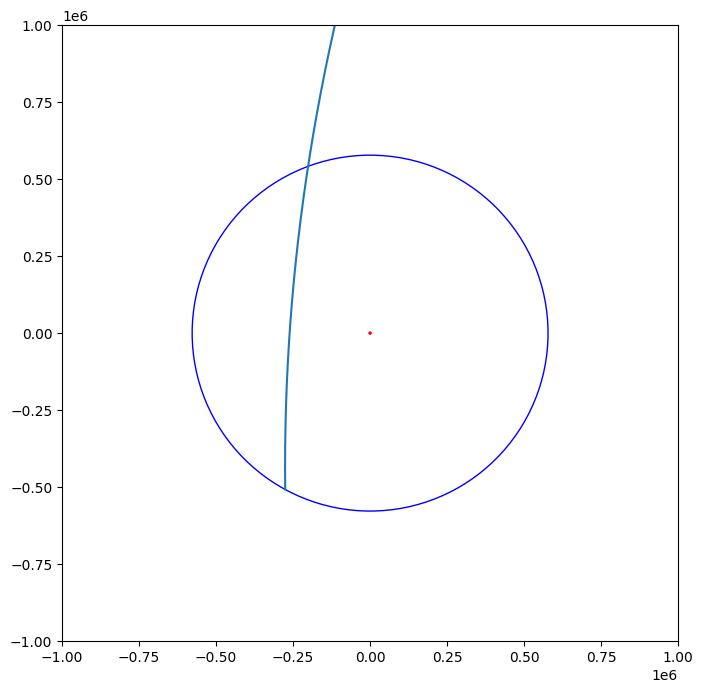

In [ ]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
plt.xlim(-1e6,+1e6)
plt.ylim(-1e6,+1e6)

plt.plot(rsx, rsy)
mars = plt.Circle((0,0), 3397.0, color = "r")
marsSOI = plt.Circle((0, 0), SOI_mars, color='b', fill=False)

ax.add_patch(mars)
ax.add_patch(marsSOI)

plt.show()

In [ ]:
# thetaPE0 = np.deg2rad(297.573)
# deltaV_LEO = 3.514668
# init_phase = np.deg2rad(44.141)

In [ ]:
def get_rPM_norm(rP, t, debug = False):
    rx_mars = D_mars*np.cos(w_mars*t + init_phase)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase)
    r_mars = np.array([rx_mars, ry_mars])
    rPM = rP - r_mars      # I think
    rPM_norm = np.linalg.norm(rPM)
    if debug:
        print(f"""
{rx_mars = }
{ry_mars = }
{r_mars = }
{rPM = }
{rPM_norm = }""")
    return rPM_norm

## DA MAIN SQUEEZE

In [75]:
class Trajectory:
    def __init__(self, yPE_geo, t_geo, yP_helio, t_helio, yPM_mars, t_mars):
        self.yPE_geo = yPE_geo
        self.t_geo = t_geo
        self.yP_helio = yP_helio
        self.t_helio = t_helio
        self.yPM_mars = yPM_mars
        self.t_mars = t_mars
        

In [76]:
def integrate_geo(ys,ts, init_phase,dt = 60,step = 0):
    solver = integrate.ode(four_body_ODE_geo)
    solver.set_integrator("lsoda") #  
    solver.set_initial_value(ys, ts[0])
    solver.set_f_params(init_phase)
    # print(solver.t, ts)

    while solver.successful():
        solver.integrate(solver.t + dt)
        ys = np.vstack((ys,solver.y))
        ts = np.vstack((ts, solver.t))
        # print(ts)
        step += 1
        # print(ys[step,:2 ])
        # print(solver.get_return_code())
        if np.linalg.norm(ys[step,:2]) > SOI_earth:
            print(f"""
Exitted SOI of Earth at
rPE = {solver.y[0]} , {solver.y[1]} km
vPE = {solver.y[2] , solver.y[3]} km/s
t = {solver.t} s \n""")
            return ys, ts, True
        
        if step > 10000:
            print("""
Failed to exit Earth SOI""")
            return ys, ts, False
        

    print(ys)
    print(ts)


In [135]:
def integrate_helio(ys, ts,init_phase, dt = 300, step = 0):
    def get_rPM_norm(rP, t, debug = False): # Im gonna fucking crash out
        rx_mars = D_mars*np.cos(w_mars*t + init_phase)
        ry_mars = D_mars*np.sin(w_mars*t + init_phase)
        r_mars = np.array([rx_mars, ry_mars])
        rPM = rP - r_mars      # I think
        rPM_norm = np.linalg.norm(rPM)
        if debug:
            print(f"""
    {rx_mars = }
    {ry_mars = }
    {r_mars = }
    {rPM = }
    {rPM_norm = }""")
        return rPM_norm
    
    solver = integrate.ode(four_body_ODE_helio)
    solver.set_integrator("lsoda") #  
    solver.set_initial_value(ys, ts[0])
    solver.set_f_params(init_phase)
    print(ys[:2])
    distance_from_mars = [get_rPM_norm(ys[:2], ts[0])]
    while solver.successful() and step < (100000*8):
        solver.integrate(solver.t + dt)
        # print(solver.t)
        ys = np.vstack((ys,solver.y))
        ts = np.vstack((ts, solver.t))
        distance_from_mars = np.vstack((distance_from_mars, get_rPM_norm([solver.y[0],solver.y[1]], solver.t)))
        step += 1
        # print(f"{solver.y[0]:e} {solver.y[1]} {solver.t / (24*60*60)}")
        # print(f"{get_rPM_norm([solver.y[0],solver.y[1]], solver.t):e} {SOI_mars:e} {(get_rPM_norm([solver.y[0],solver.y[1]], solver.t) - SOI_mars):e} ")
        if (get_rPM_norm([solver.y[0],solver.y[1]], solver.t) - SOI_mars) < 5e5:
            dt = 300

        if get_rPM_norm([solver.y[0],solver.y[1]], solver.t) < SOI_mars:
            print(f"""
Enterred SOI of Mars at
rP = {solver.y[0]:e} , {solver.y[1]:e} km
vP = {solver.y[2] , solver.y[3]} km/s
t = {solver.t} s\n""")
            return ys, ts, True, 0 
        
#         if solver.y[0] < 0:
#             if get_rPM_norm([ys[-1,0],ys[-1,1]], ts[-1]) < get_rPM_norm([ys[-2,0],ys[-2,1]], ts[-2]):
#                 print(f"""
# {get_rPM_norm([ys[-1,0],ys[-1,1]], ts[-1]) = }
# {get_rPM_norm([ys[-2,0],ys[-2,1]], ts[-2]) = }
# Swing and a miss """)
#                 return -1, ts

        if (solver.t/(60*60*24)) > 400:
            print(f"""
Failed to Enter Mars SOI
Closest to Mars at {np.min(distance_from_mars)}""")
            return ys, ts, False, np.min(distance_from_mars)

    print(ys, ts)

In [ ]:
def integrate_mars(ys, ts,init_phase,deltaV_LMO, dt = 60, step = 0):
    solver = integrate.ode(four_body_ODE_mars)
    solver.set_integrator("lsoda") #  
    solver.set_initial_value(ys, ts[0])
    solver.set_f_params(init_phase)

    while solver.successful():
        solver.integrate(solver.t + dt)
        ys = np.vstack((ys,solver.y))
        ts = np.vstack((ts, solver.t))
        step += 1
        # print(ys[step,:2 ])
        # print(solver.get_return_code())
        if np.linalg.norm(ys[step,:2]) < R_LMO: # Not sure if this is a good way of doing it
            print(f"""
Reached desired height of Mars orbit at
rPM = {solver.y[0]} , {solver.y[1]} km
vPM = {solver.y[2] , solver.y[3]} km/s
t = {solver.t} s\n""")
            return ys, ts, abs(g1(solver.y[0],solver.y[1])) + abs(g2(solver.y[2],solver.y[3], deltaV_LMO)) + abs(g3(solver.y[0],solver.y[1],solver.y[2],solver.y[3], deltaV_LMO, orientation="counterclockwise"))
            # return ys, ts, g(solver.y[0],solver.y[1],solver.y[2],solver.y[3], deltaV_LMO, debug= True)
        
        if np.linalg.norm(ys[step,:2]) > np.linalg.norm(ys[step - 1,:2]):
            print(f"""
Swing and a miss
Closest distance = {np.linalg.norm(ys[step - 1,:2])} km""")
            return ys, ts, abs(g1(solver.y[0],solver.y[1])) + abs(g2(solver.y[2],solver.y[3], deltaV_LMO)) + abs(g3(solver.y[0],solver.y[1],solver.y[2],solver.y[3], deltaV_LMO, orientation="counterclockwise"))
            # return ys, ts, g(solver.y[0],solver.y[1],solver.y[2],solver.y[3], deltaV_LMO)
        if step > 8000*3:
            print(f"Failed to solve for constraints in time")
            return -1, ts, np.inf

    # if g(solver.y[0], solver.y[1], solver.y[2], solver.y[3], deltaV_LMO):
    #     break

# print(ys)
# print(ts)

In [96]:
def simulate(thetaPE0, init_phase, deltaV_LEO, deltaV_LMO): # Give angles in degrees
    # Success Flags
    geo_success = False
    helio_success = False
    mars_success = False

    # Initialize trajectory
    yPE_geo = t_geo = yP_helio = t_helio = yPM_mars = t_mars = 0

    ############GEOCENTRIC#####################
    # timestep 
    dt = 60.0

    # Parameters
    thetaPE0 = np.deg2rad(thetaPE0)
    init_phase = np.deg2rad(init_phase)
    deltaV_LEO = deltaV_LEO
    deltaV_LMO = deltaV_LMO

    # IC for geocentric phase
    rPEx0 = R_LEO*np.cos(thetaPE0) # thetaPE0 to be perscribed
    rPEy0 = R_LEO*np.sin(thetaPE0) # thetaPE0 to be perscribed

    vPEx0 = -(np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.sin(thetaPE0)
    vPEy0 = (np.sqrt(mu_earth/R_LEO) + deltaV_LEO) * np.cos(thetaPE0)
    # print(np.sqrt(mu_earth/R_LEO) * np.sin(thetaPE0))
    # print(vPEy0)

    y0 =np.array([rPEx0, rPEy0, vPEx0, vPEy0], None)
    ys = y0
    ts = [0]
    print(ys, ts)
    yPE_geo, t_geo, geo_success = integrate_geo(ys, ts, init_phase, dt=dt)
    if geo_success == False:
        objective = 20e50

    #################HELIOCENTRIC#####################
    
    if geo_success:
        # timestep 
        dt = 60*20

        t1 = t_geo[-1]
        rPEx1, rPEy1, vPEx1, vPEy1 = yPE_geo[-1]
        # Earth Pos and Vel
        rx_earth1 = D_earth*np.cos(w_earth*t1)
        ry_earth1 = D_earth*np.sin(w_earth*t1)

        vx_earth1 = -w_earth*D_earth*np.sin(w_earth*t1)
        vy_earth1 = w_earth*D_earth*np.cos(w_earth*t1)
    
        # initial conditions
        rPx1 = rx_earth1 + rPEx1 
        rPy1 = ry_earth1 + rPEy1 

        vPx1 = vx_earth1 + vPEx1 
        vPy1 = vy_earth1 + vPEy1 

        y1 =np.array([rPx1[0], rPy1[0], vPx1[0], vPy1[0]])

        ys = y1
        ts = t1
        yP_helio, t_helio, helio_success, closest_to_mars = integrate_helio(ys, ts, init_phase, dt = dt)
        if helio_success == False:
            objective = closest_to_mars*10
        # print(f"{yP_helio} test")
        # if np.size(yP_helio) == 1:
        #     objective = dist_from_mars**2
        #     helio_success = False
        # else:
        #     helio_success = True

    ###################MARSCENTRIC########################
    # timestep
    if helio_success:
        # timestep
        dt = 60

        rPx2, rPy2, vPx2, vPy2 = yP_helio[-1]
        t2 = t_helio[-1]

        # Mars Pos and Vel
        rx_mars2 = D_mars*np.cos(w_mars*t2 + init_phase)
        ry_mars2 = D_mars*np.sin(w_mars*t2 + init_phase)

        vx_mars2 = -w_mars*D_mars*np.sin(w_mars*t2 + init_phase)
        vy_mars2 = w_mars*D_mars*np.cos(w_mars*t2 + init_phase)

        # Initial Conditions
        rPMx2 = rPx2 - rx_mars2
        rPMy2 = rPy2 - ry_mars2

        vPMx2 = vPx2 - vx_mars2
        vPMy2 = vPy2 - vy_mars2

        y2 =np.array([rPMx2[0], rPMy2[0], vPMx2[0], vPMy2[0]], None)

        ys = y2
        ts = t2

        # print(ys , ts)
        yPM_mars, t_mars, objective = integrate_mars(ys, ts,init_phase, deltaV_LMO ,dt = dt)
        if np.size(yPM_mars) == 1:
            objective = np.inf
            mars_success = False
        else:
            mars_success = True
            print(f"""
{deltaV_LEO = }
{deltaV_LMO = }""")


    return objective, Trajectory(yPE_geo, t_geo, yP_helio, t_helio, yPM_mars, t_mars)




    




In [93]:
thetaPE0 = 297.573
deltaV_LEO = 3.7
deltaV_LMO = 2.087434
init_phase = 44.141

result, trajectory = simulate(thetaPE0, init_phase, deltaV_LEO, deltaV_LMO)

[ 3.16664351e+03 -6.06418885e+03  1.00459311e+01  5.24585948e+00] [0]

Exitted SOI of Earth at
rPE = 123463.90362661547 , 915389.8376286895 km
vPE = (np.float64(0.3954783017861955), np.float64(3.54770873679626)) km/s
t = 239760.0 s 

[1.49552913e+08 8.05679679e+06]

Failed to Enter Mars SOI
Closest to Mars at 10194397.701755507


In [137]:
initial_guess = [3.5126239830676917,2.102583498677658]


def wrapped_simulate(x):
    thetaPE0 = 297.573
    init_phase = 44.141
    deltaV_LEO, deltaV_LMO = x
    objective = simulate(thetaPE0, init_phase,deltaV_LEO,deltaV_LMO)[0]
    print(objective)
    return objective

soln = optimize.minimize(wrapped_simulate,initial_guess,bounds=((3.49,3.52),(2.08,2.14)))
print(f"""DeltaV_LEO = {soln.x[0]} km/s    \nDeltaV_LMO= {soln.x[1]} km/s
{soln.status}
{soln.message}
{soln}""")

[ 3.16664351e+03 -6.06418885e+03  9.87983693e+00  5.15912717e+00] [0]

Exitted SOI of Earth at
rPE = 33091.47599818115 , 923061.0382976681 km
vPE = (np.float64(0.0231280923505573), np.float64(2.9202541495398107)) km/s
t = 285720.0 s 

[1.49390907e+08 9.43205725e+06]

Enterred SOI of Mars at
rP = -2.278501e+08 , 5.423572e+06 km
vP = (np.float64(-0.6062643191384977), np.float64(-21.447229046590685)) km/s
t = 22152420.0 s


Reached desired height of Mars orbit at
rPM = 3496.5607419629177 , -841.2418678273789 km
vPM = (np.float64(0.2727354832109302), np.float64(2.6645239040827398)) km/s
t = 22368420.0 s


deltaV_LEO = np.float64(3.5126239830676917)
deltaV_LMO = np.float64(2.102583498677658)
15236.71996361958
[ 3.16664351e+03 -6.06418885e+03  9.87983694e+00  5.15912718e+00] [0]

Exitted SOI of Earth at
rPE = 33091.48161213459 , 923061.0474624403 km
vPE = (np.float64(0.023128111193672425), np.float64(2.9202541859596303)) km/s
t = 285720.0 s 

[1.49390907e+08 9.43205725e+06]

Enterred SOI of 

In [136]:
initial_guess = [3.5,2.5]


def wrapped_simulate(x):
    thetaPE0 = 297
    init_phase = 44
    deltaV_LEO, deltaV_LMO = x
    objective = simulate(thetaPE0, init_phase,deltaV_LEO,deltaV_LMO)[0]
    print(objective)
    return objective

soln = optimize.minimize(wrapped_simulate,initial_guess,bounds=((2,10),(2,10)))
print(f"""DeltaV_LEO = {soln.x[0]} km/s    \nDeltaV_LMO= {soln.x[1]} km/s
{soln.status}
{soln.message}
{soln}""")

[ 3.10583981e+03 -6.09555383e+03  9.91968903e+00  5.05433401e+00] [0]

Exitted SOI of Earth at
rPE = 35271.2831738985 , 922990.8617727672 km
vPE = (np.float64(0.028314761212273346), np.float64(2.871647739024235)) km/s
t = 289860.0 s 

[1.49386019e+08 9.55514392e+06]

Failed to Enter Mars SOI
Closest to Mars at 2359226.7295950316
23592267.295950316
[ 3.10583981e+03 -6.09555383e+03  9.91968904e+00  5.05433402e+00] [0]

Exitted SOI of Earth at
rPE = 35271.28892563269 , 922990.8711747125 km
vPE = (np.float64(0.028314780239535743), np.float64(2.871647775937195)) km/s
t = 289860.0 s 

[1.49386019e+08 9.55514393e+06]

Failed to Enter Mars SOI
Closest to Mars at 2359224.3849267475
23592243.849267475
[ 3.10583981e+03 -6.09555383e+03  9.91968903e+00  5.05433401e+00] [0]

Exitted SOI of Earth at
rPE = 35271.2831738985 , 922990.8617727672 km
vPE = (np.float64(0.028314761212273346), np.float64(2.871647739024235)) km/s
t = 289860.0 s 

[1.49386019e+08 9.55514392e+06]

Failed to Enter Mars SOI
Closes

KeyboardInterrupt: 

In [139]:
thetaPE0 = 297.573
deltaV_LEO = soln.x[0]
deltaV_LMO = soln.x[1]
init_phase = 44.141

objective, trajectory  = simulate(thetaPE0, init_phase, deltaV_LEO, deltaV_LMO)

[ 3.16664351e+03 -6.06418885e+03  9.87983693e+00  5.15912717e+00] [0]

Exitted SOI of Earth at
rPE = 33091.47599818115 , 923061.0382976681 km
vPE = (np.float64(0.0231280923505573), np.float64(2.9202541495398107)) km/s
t = 285720.0 s 

[1.49390907e+08 9.43205725e+06]

Enterred SOI of Mars at
rP = -2.278501e+08 , 5.423572e+06 km
vP = (np.float64(-0.6062643191384977), np.float64(-21.447229046590685)) km/s
t = 22152420.0 s


Reached desired height of Mars orbit at
rPM = 3496.5607419629177 , -841.2418678273789 km
vPM = (np.float64(0.2727354832109302), np.float64(2.6645239040827398)) km/s
t = 22368420.0 s


deltaV_LEO = np.float64(3.5126239830676917)
deltaV_LMO = np.float64(2.102583498677658)


In [128]:
thetaPE0 = 297
deltaV_LEO = soln.x[0]
deltaV_LMO = soln.x[1]
init_phase = 44

objective, trajectory  = simulate(thetaPE0, init_phase, deltaV_LEO, deltaV_LMO)

[ 3.10583981e+03 -6.09555383e+03  1.12561988e+01  5.73531976e+00] [0]

Exitted SOI of Earth at
rPE = 443838.73616146983 , 809900.2657563877 km
vPE = (np.float64(3.1045487909845253), np.float64(5.855191930628907)) km/s
t = 135420.0 s 

[1.49989423e+08 4.84451697e+06]

Failed to Enter Mars SOI
Closest to Mars at 56339969.32224028


In [115]:
print(trajectory.t_mars[-1]/(60*60*24))

TypeError: 'int' object is not subscriptable

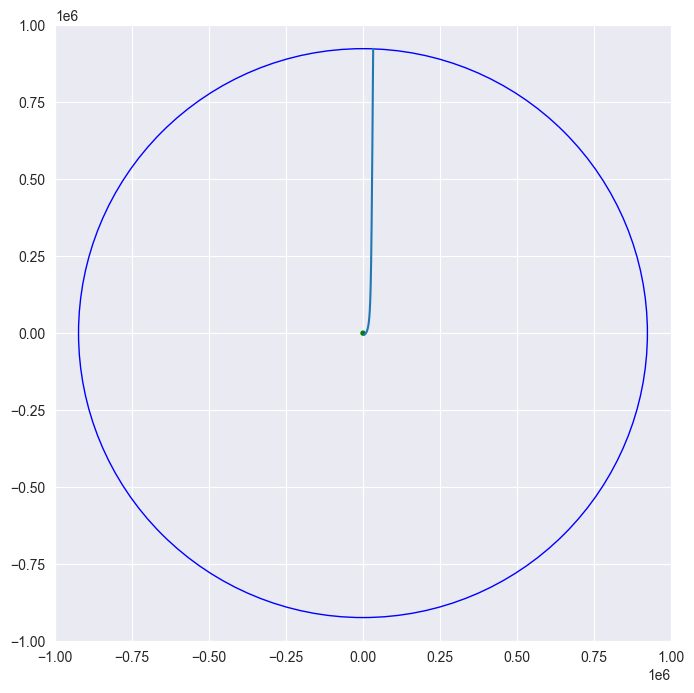

In [140]:
def plot_geo_wide(yPE_geo):
    rs = yPE_geo[:,:2]
    rsx = rs.T[0]
    rsy = rs.T[1]

    fig, ax = plt.subplots(figsize = (13,8))
    ax.set_aspect(1)
    plt.xlim(-1e6,+1e6)
    plt.ylim(-1e6,+1e6)

    plt.plot(rsx, rsy)
    earth = plt.Circle((0,0), 6378.2, color = "g")
    earthSOI = plt.Circle((0, 0), SOI_earth, color='b', fill=False)

    ax.add_patch(earth)
    ax.add_patch(earthSOI)

    plt.show()

plot_geo_wide(trajectory.yPE_geo)

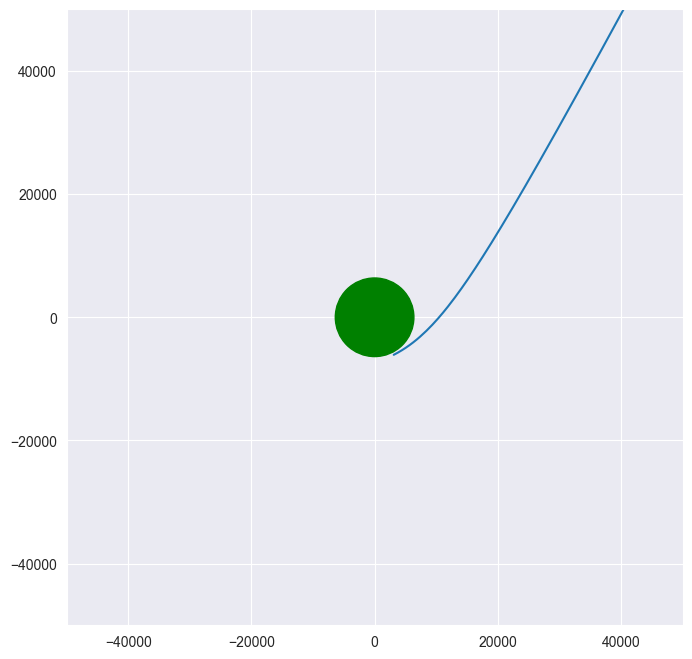

In [138]:
def plot_geo_tight(yPE_geo):
    rs = yPE_geo[:,:2]
    rsx = rs.T[0]
    rsy = rs.T[1]

    fig, ax = plt.subplots(figsize = (13,8))
    ax.set_aspect(1)
    plt.xlim(-5e4,+5e4)
    plt.ylim(-5e4,+5e4)

    plt.plot(rsx, rsy)
    earth = plt.Circle((0,0), 6378.2, color = "g")
    earthSOI = plt.Circle((0, 0), SOI_earth, color='b', fill=False)

    ax.add_patch(earth)
    ax.add_patch(earthSOI)

    plt.show()

plot_geo_tight(trajectory.yPE_geo)

2.3448555214385403


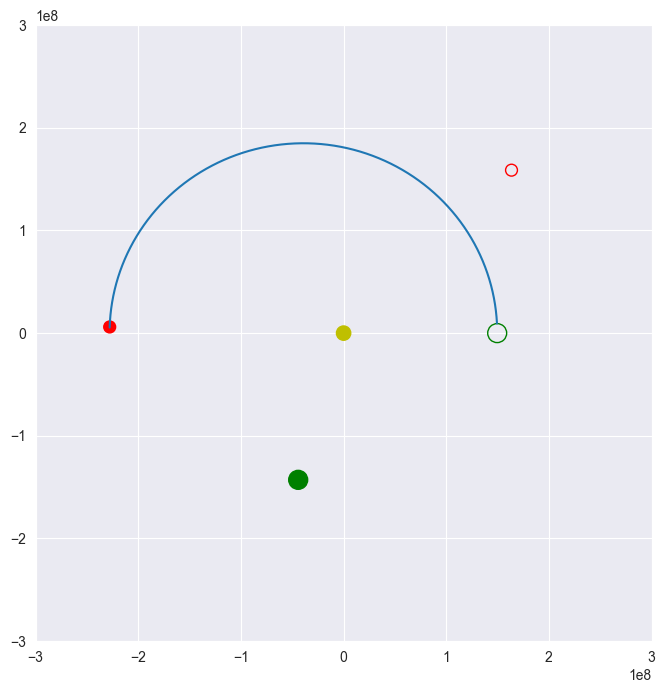

In [141]:
def plot_wide_helio(yP_helio, t_helio, init_phase):
    init_phase = np.deg2rad(init_phase)
    t1 = 0
    t2 = t_helio[-1][0]

    rs = yP_helio[:,:2]
    rsx = rs.T[0]
    rsy = rs.T[1]

    # Pos of Earth at t1
    rx_earth1 = D_earth*np.cos(w_earth*t1)
    ry_earth1 = D_earth*np.sin(w_earth*t1)

    # Pos of Mars at t1
    rx_mars1 = D_mars*np.cos(w_mars*t1 + init_phase)
    ry_mars1 = D_mars*np.sin(w_mars*t1 + init_phase)

    # Pos of Mars at t2
    rx_mars2 = D_mars*np.cos(w_mars*t2 + init_phase)
    ry_mars2 = D_mars*np.sin(w_mars*t2 + init_phase)

    print((w_mars*t2))
    # Pos of Earth at t2 
    rx_earth2 = D_earth*np.cos(w_earth*t2)
    ry_earth2 = D_earth*np.sin(w_earth*t2)


    fig, ax = plt.subplots(figsize = (13,8))

    # Scale for Sun and planet SOI visualisation
    scaling_factor = 10
    ax.set_aspect(1)
    plt.xlim(-3e8,+3e8)
    plt.ylim(-3e8,+3e8)

    plt.plot(rsx, rsy)

    earth1SOI = plt.Circle((rx_earth1, ry_earth1), SOI_earth*scaling_factor, color='g', fill=False)
    earth2SOI = plt.Circle((rx_earth2, ry_earth2), SOI_earth*scaling_factor, color='g', fill=True)

    mars1SOI = plt.Circle((rx_mars1, ry_mars1), SOI_mars*scaling_factor, color='r', fill=False)
    mars2SOI = plt.Circle((rx_mars2, ry_mars2), SOI_mars*scaling_factor, color='r', fill=True)
    # mars3SOI = plt.Circle((rx_mars3, ry_mars3), SOI_mars*1, color='y', fill=False)

    Sun = plt.Circle((0, 0), 696340*scaling_factor, color='y', fill=True)

    ax.add_patch(earth1SOI)
    ax.add_patch(earth2SOI)

    ax.add_patch(mars1SOI)
    ax.add_patch(mars2SOI)
    # ax.add_patch(mars3SOI)

    ax.add_patch(Sun)
    
    plt.show()

plot_wide_helio(trajectory.yP_helio, trajectory.t_helio, init_phase)

2.3448428193201


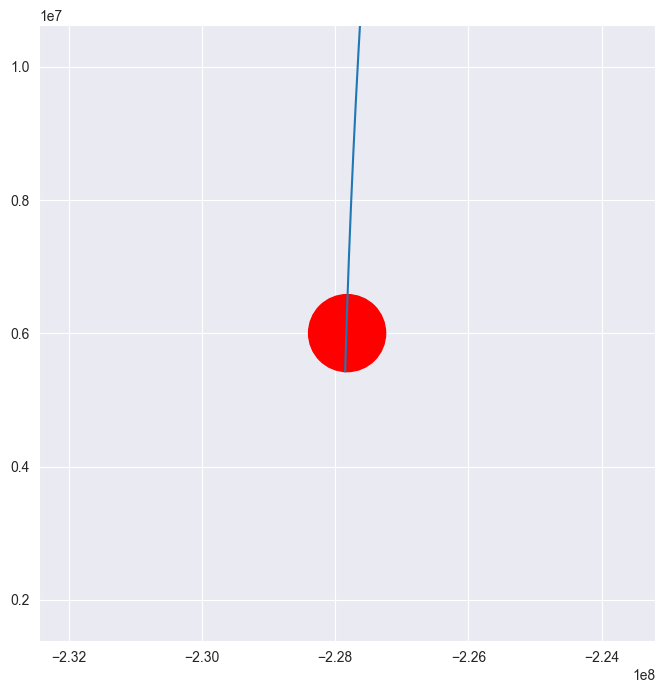

In [ ]:
def plot_tight_helio(yP_helio, t_helio, init_phase):
    init_phase = np.deg2rad(init_phase)
    t1 = 0
    t2 = t_helio[-1][0]

    rs = yP_helio[:,:2]
    rsx = rs.T[0]
    rsy = rs.T[1]

    # Pos of Earth at t1
    rx_earth1 = D_earth*np.cos(w_earth*t1)
    ry_earth1 = D_earth*np.sin(w_earth*t1)

    # Pos of Mars at t1
    rx_mars1 = D_mars*np.cos(w_mars*t1 + init_phase)
    ry_mars1 = D_mars*np.sin(w_mars*t1 + init_phase)

    # Pos of Mars at t2
    rx_mars2 = D_mars*np.cos(w_mars*t2 + init_phase)
    ry_mars2 = D_mars*np.sin(w_mars*t2 + init_phase)

    print((w_mars*t2))
    # Pos of Earth at t2 
    rx_earth2 = D_earth*np.cos(w_earth*t2)
    ry_earth2 = D_earth*np.sin(w_earth*t2)


    fig, ax = plt.subplots(figsize = (13,8))
    ax.set_aspect(1)
    plt.xlim(rx_mars2 - SOI_mars*8,rx_mars2 + SOI_mars*8)
    plt.ylim(ry_mars2 - SOI_mars*8,ry_mars2 + SOI_mars*8)

    plt.plot(rsx, rsy, markersize = 1)
    plt.plot()

    # earth1SOI = plt.Circle((rx_earth1[0], ry_earth1[0]), SOI_earth*1, color='g', fill=False)
    # earth2SOI = plt.Circle((rx_earth2, ry_earth2), SOI_earth*1, color='g', fill=True)

    # mars1SOI = plt.Circle((rx_mars1[0], ry_mars1[0]), SOI_mars*1, color='r', fill=False)
    mars2SOI = plt.Circle((rx_mars2, ry_mars2), SOI_mars*1, color='r', fill=True)
    # mars3SOI = plt.Circle((rx_mars3, ry_mars3), SOI_mars*1, color='y', fill=False)

    # Sun = plt.Circle((0, 0), 696340*1, color='y', fill=True)

    # ax.add_patch(earth1SOI)
    # ax.add_patch(earth2SOI)

    # ax.add_patch(mars1SOI)
    ax.add_patch(mars2SOI)
    # ax.add_patch(mars3SOI)
    # ax.add_patch(Sun)

    plt.show()

plot_tight_helio(trajectory.yP_helio,trajectory.t_helio,init_phase)

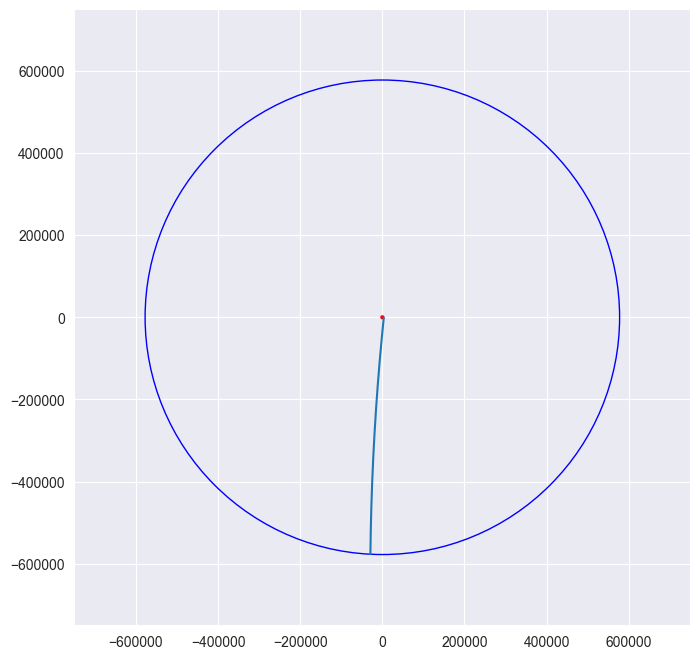

In [142]:
def plot_mars_wide(yPM_mars):
    rs = yPM_mars[:,:2]
    rsx = rs.T[0]
    rsy = rs.T[1]

    fig, ax = plt.subplots(figsize = (13,8))
    ax.set_aspect(1)
    plt.xlim(-0.75e6,+.75e6)
    plt.ylim(-.75e6,+.75e6)

    plt.plot(rsx, rsy)
    mars = plt.Circle((0,0), 3397.0, color = "r")
    marsSOI = plt.Circle((0, 0), SOI_mars, color='b', fill=False)

    ax.add_patch(mars)
    ax.add_patch(marsSOI)

    plt.show()

plot_mars_wide(trajectory.yPM_mars)

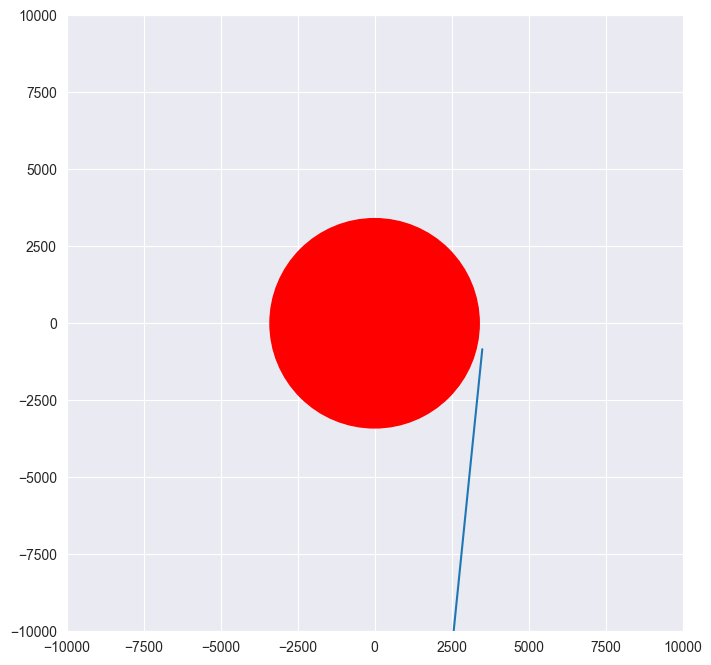

In [143]:
def plot_mars_tight(yPM_mars):
    rs = yPM_mars[:,:2]
    rsx = rs.T[0]
    rsy = rs.T[1]

    fig, ax = plt.subplots(figsize = (13,8))
    ax.set_aspect(1)
    plt.xlim(-1e4,+1e4)
    plt.ylim(-1e4,+1e4)

    plt.plot(rsx, rsy)
    mars = plt.Circle((0,0), 3397.0, color = "r")
    marsSOI = plt.Circle((0, 0), SOI_mars, color='b', fill=False)

    ax.add_patch(mars)
    ax.add_patch(marsSOI)

    plt.show()

plot_mars_tight(trajectory.yPM_mars)

(21218, 4)
